In [4]:
import os
import random
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import yaml
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import ultralytics
from ultralytics import YOLO
from sklearn.model_selection import train_test_split

Primeira imagem: /home/pvbm.eng23/dataset_topicos/images_train/100018.png


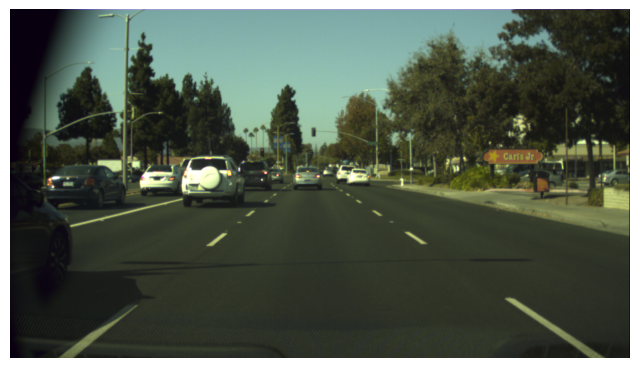

In [50]:
path = Path("/home/pvbm.eng23/dataset_topicos/images_train")

print(f"Primeira imagem: {imagens[0]}")

img = Image.open(imagens[0])

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
a = torch.rand(1000, 4, device="cuda")
b = torch.rand(1000, 4, device="cuda")

for _ in range(1000):
    c = torch.min(a.unsqueeze(1), b.unsqueeze(0))

In [64]:
random.seed(42)

images_path = dataset_path / "images_train"

imgs= list(Path(images_path).glob("*.png"))

saida = dataset_path / "dataset_yolo"

treino = 1000
validacao = 150
teste = 300

random.seed(42)

imgs = random.sample(imgs, 1450)

train_imgs, temp_imgs = train_test_split(
    imgs,
    train_size=1000,
    random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs,
    train_size=150,
    random_state=42
)

print(len(train_imgs))
print(len(val_imgs))
print(len(test_imgs))

1000
150
300


In [62]:
for pasta in ["train", "val", "test"]:
    (dataset_path / "images" / pasta).mkdir(
        parents=True,
        exist_ok=True
    )

    (dataset_path / "labels" / pasta).mkdir(
        parents=True,
        exist_ok=True
    )

In [65]:
for img in train_imgs:
    shutil.copy2(
        img,
        dataset_path / "images/train" / img.name
    )

for img in val_imgs:
    shutil.copy2(
        img,
        dataset_path / "images/val" / img.name
    )

for img in test_imgs:
    shutil.copy2(
        img,
        dataset_path / "images/test" / img.name
    )

In [56]:
train_names = {img.name for img in train_imgs}
val_names = {img.name for img in val_imgs}
test_names = {img.name for img in test_imgs}

In [57]:
CLASS_MAP = {
    "Red": 0,
    "RedLeft": 0,
    "RedRight": 0,

    "Yellow": 1,
    "YellowLeft": 1,
    "YellowRight": 1,

    "Green": 2,
    "GreenLeft": 2,
    "GreenRight": 2
}

In [81]:
for item in data:

    nome = Path(item["path"]).name

    if nome in train_names:
        split = "train"

    elif nome in val_names:
        split = "val"

    elif nome in test_names:
        split = "test"

    else:
        continue

    img_path = (
        dataset_path /
        "images" /
        split /
        nome
    )

    width, height = Image.open(img_path).size

    linhas = []

    for box in item["boxes"]:

        label = box["label"]

        if label not in CLASS_MAP:
            continue

        cls = CLASS_MAP[label]

        xmin = box["x_min"]
        xmax = box["x_max"]
        ymin = box["y_min"]
        ymax = box["y_max"]
        xmin = max(0, xmin)
        ymin = max(0, ymin)
        xmax = min(width, xmax)
        ymax = min(height, ymax)

        if xmax <= xmin or ymax <= ymin:
            continue

        xc = ((xmin + xmax) / 2) / width
        yc = ((ymin + ymax) / 2) / height

        bw = (xmax - xmin) / width
        bh = (ymax - ymin) / height

        linhas.append(
            f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"
        )

    label_file = (
        dataset_path /
        "labels" /
        split /
        f"{Path(nome).stem}.txt"
    )

    with open(label_file, "w") as f:
        f.write("\n".join(linhas))

In [82]:
data_yaml = """
path: /home/pvbm.eng23/dataset_topicos

train: images/train
val: images/val
test: images/test

names:
  0: Red
  1: Yellow
  2: Green
"""

with open(
    dataset_path / "data.yaml",
    "w"
) as f:
    f.write(data_yaml)

In [83]:
contagem = Counter()

for item in validas:
    for box in item["boxes"]:

        label = box["label"]

        if label not in CLASS_MAP:
            continue

        contagem[CLASS_MAP[label]] += 1

print(contagem)

Counter({2: 1782, 0: 1350, 1: 182})


In [4]:
model = YOLO("yolo26n.pt")

results = model.train(
    data="/home/pvbm.eng23/dataset_topicos/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.62 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GB10, 122501MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/pvbm.eng23/dataset_topicos/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [5]:
model = YOLO("runs/detect/train-7/weights/best.pt")
folder = "images/test"

images = sorted([
    f for f in os.listdir(folder)
    if f.lower().endswith(".png")
])

predict_image = os.path.join(folder, images[100])


results = model.predict(
        source=predict_image,
        conf=0.25,
        show=True,
        save=True
    )

WARNING Environment does not support cv2.imshow() or PIL Image.show()
OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


image 1/1 c:\Users\agrda\OneDrive\rea de Trabalho\yolo-bosch-traffic-lights\images\test\17174.png: 384x640 2 Reds, 2 Greens, 145.8ms
Speed: 8.7ms preprocess, 145.8ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\agrda\OneDrive\rea de Trabalho\yolo-bosch-traffic-lights\runs\detect\predict-6


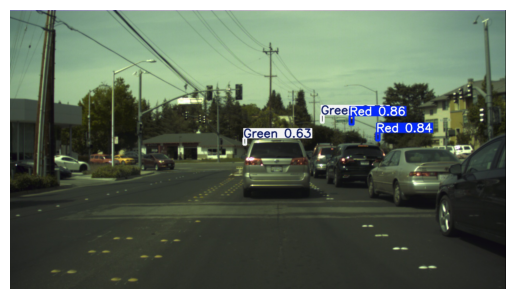

In [8]:
salvo = next(Path(results[0].save_dir).glob(f"{Path(predict_image).stem}.*"))
img = Image.open(salvo)

plt.imshow(img)
plt.axis("off")
plt.show()

In [9]:
MODEL_PATH = "runs/detect/train-7/weights/best.pt"
DATA_YAML  = "data.yaml"

model = YOLO(MODEL_PATH)

metrics = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    conf=0.001,
    iou=0.6,
    plots=True,
    verbose=True,
)

print("\nResultados e graficos salvos em:", metrics.save_dir)

Ultralytics 8.4.62  Python-3.13.0 torch-2.12.0+cpu CPU (Intel Core Ultra 7 155H)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 108.022.2 MB/s, size: 1155.2 KB)
val: Scanning C:\Users\agrda\OneDrive\Área de Trabalho\yolo-bosch-traffic-lights\labels\test... 300 images, 124 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 148.5it/s 2.0s0.1s
val: New cache created: C:\Users\agrda\OneDrive\rea de Trabalho\yolo-bosch-traffic-lights\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.5s/it 29.1s1.5ss
                   all        300        569      0.652      0.488      0.515      0.268
                   Red        100        213      0.761      0.667      0.716      0.366
                Yellow         23         33      0.345     0.0606     0.0507     0.0319
                 Green        121        323      0.851      0.737

In [10]:
names = model.names

print("===== Metricas globais - conjunto de TESTE =====")
print(f"Precisao (media):  {metrics.box.mp:.4f}")
print(f"Recall (media):    {metrics.box.mr:.4f}")
print(f"mAP@50:            {metrics.box.map50:.4f}")
print(f"mAP@75:            {metrics.box.map75:.4f}")
print(f"mAP@50-95:         {metrics.box.map:.4f}")

linhas = []
for i, c in enumerate(metrics.box.ap_class_index):
    p, r, ap50, ap = metrics.box.class_result(i)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    linhas.append({
        "classe":    names[int(c)],
        "Precisao":  round(p, 4),
        "Recall":    round(r, 4),
        "F1":        round(f1, 4),
        "mAP@50":    round(ap50, 4),
        "mAP@50-95": round(ap, 4),
    })

df_metrics = pd.DataFrame(linhas)
df_metrics

===== Metricas globais - conjunto de TESTE =====
Precisao (media):  0.6522
Recall (media):    0.4880
mAP@50:            0.5148
mAP@75:            0.2298
mAP@50-95:         0.2682


,classe,Precisao,Recall,F1,mAP@50,mAP@50-95
0,Red,0.7610,0.6667,0.7107,0.7157,0.3658
1,Yellow,0.3450,0.0606,0.1031,0.0507,0.0319
2,Green,0.8506,0.7368,0.7896,0.7779,0.4070


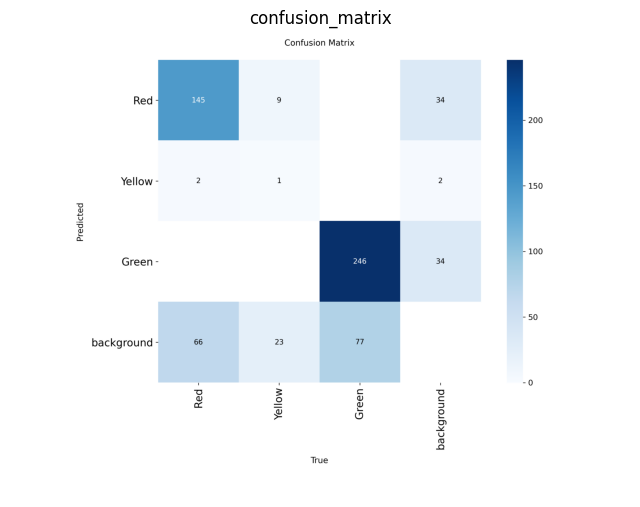

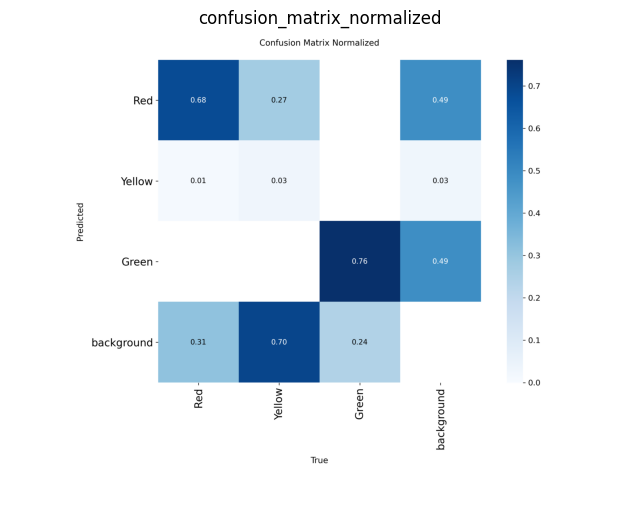


Matriz de confusao (linhas = Predito, colunas = Verdadeiro):


,Red,Yellow,Green,background
Red,145,9,0,34
Yellow,2,1,0,2
Green,0,0,246,34
background,66,23,77,0


In [11]:
save_dir = Path(metrics.save_dir)

for nome in ["confusion_matrix.png", "confusion_matrix_normalized.png"]:
    caminho = save_dir / nome
    if caminho.exists():
        plt.figure(figsize=(8, 7))
        plt.imshow(Image.open(caminho))
        plt.axis("off")
        plt.title(nome.replace(".png", ""))
        plt.show()
    else:
        print("Nao encontrado:", caminho)

cm = metrics.confusion_matrix.matrix.astype(int)
rotulos = [model.names[i] for i in range(len(model.names))] + ["background"]
df_cm = pd.DataFrame(cm, index=rotulos, columns=rotulos)
print("\nMatriz de confusao (linhas = Predito, colunas = Verdadeiro):")
df_cm

In [12]:
TEST_IMG_DIR = Path("images/test")
TEST_LBL_DIR = Path("labels/test")

CONF_VIS = 0.25   
IOU_MATCH = 0.5   


def carregar_gt(label_path, W, H):
    """Le labels YOLO (cls xc yc w h normalizados) -> [(cls, x1, y1, x2, y2), ...]"""
    caixas = []
    if not Path(label_path).exists():
        return caixas
    for linha in open(label_path):
        linha = linha.strip()
        if not linha:
            continue
        cls, xc, yc, bw, bh = map(float, linha.split())
        x1 = (xc - bw / 2) * W
        y1 = (yc - bh / 2) * H
        x2 = (xc + bw / 2) * W
        y2 = (yc + bh / 2) * H
        caixas.append((int(cls), x1, y1, x2, y2))
    return caixas


def iou(a, b):
    x1 = max(a[0], b[0]); y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    if inter == 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter)


imagens_teste = sorted(TEST_IMG_DIR.glob("*.png"))
registros = []

for img_path in imagens_teste:
    W, H = Image.open(img_path).size
    gts = carregar_gt(TEST_LBL_DIR / f"{img_path.stem}.txt", W, H)

    res = model.predict(img_path, conf=CONF_VIS, iou=0.6, verbose=False)[0]
    preds = []
    for box in res.boxes:
        cls = int(box.cls[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        preds.append((cls, x1, y1, x2, y2, float(box.conf[0])))

    gt_casados = set()
    tp = fp = erro_classe = 0
    for p in sorted(preds, key=lambda z: -z[5]):
        melhor_iou, melhor_j = 0.0, -1
        for j, g in enumerate(gts):
            if j in gt_casados:
                continue
            v = iou(p[1:5], g[1:5])
            if v > melhor_iou:
                melhor_iou, melhor_j = v, j
        if melhor_iou >= IOU_MATCH and melhor_j >= 0:
            gt_casados.add(melhor_j)
            if gts[melhor_j][0] == p[0]:
                tp += 1            
            else:
                erro_classe += 1   
        else:
            fp += 1          
    fn = len(gts) - len(gt_casados)   
    erros = fp + fn + erro_classe

    registros.append({
        "img": img_path,
        "n_gt": len(gts),
        "n_pred": len(preds),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "erro_classe": erro_classe,
        "erros": erros,
    })

df_reg = pd.DataFrame(registros)

perfeitas = df_reg[(df_reg.erros == 0) & (df_reg.n_gt > 0)]
com_erro = df_reg[df_reg.erros > 0]

print(f"Total de imagens de teste:        {len(df_reg)}")
print(f"Imagens perfeitas (0 erros, >=1 objeto): {len(perfeitas)}")
print(f"Imagens com algum erro:           {len(com_erro)}")
print(f"\nTotais  ->  TP: {df_reg.tp.sum()} | FP: {df_reg.fp.sum()} | "
      f"FN: {df_reg.fn.sum()} | erro_classe: {df_reg.erro_classe.sum()}")
df_reg.head()

Total de imagens de teste:        300
Imagens perfeitas (0 erros, >=1 objeto): 56
Imagens com algum erro:           122

Totais  ->  TP: 384 | FP: 83 | FN: 175 | erro_classe: 10


,img,n_gt,n_pred,tp,fp,fn,erro_classe,erros
0,images\test\100436.png,0,0,0,0,0,0,0
1,images\test\100574.png,1,0,0,0,1,0,1
2,images\test\101060.png,3,4,3,1,0,0,1
3,images\test\101130.png,3,3,3,0,0,0,0
4,images\test\101200.png,3,3,3,0,0,0,0


EXEMPLOS BEM SUCEDIDOS


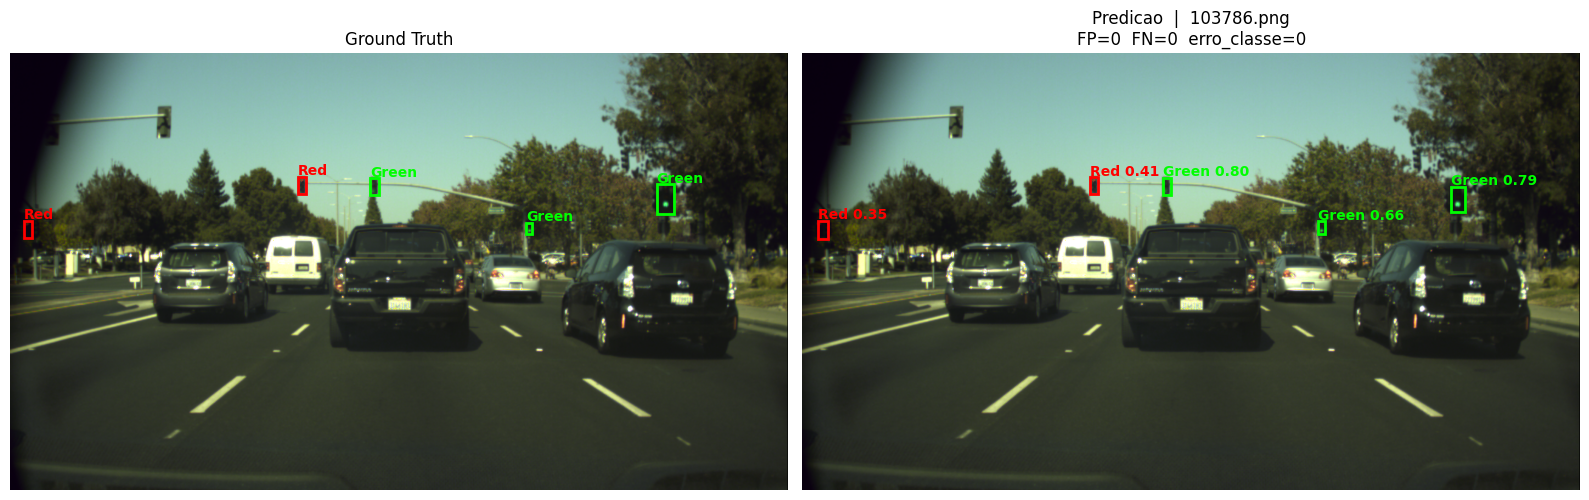

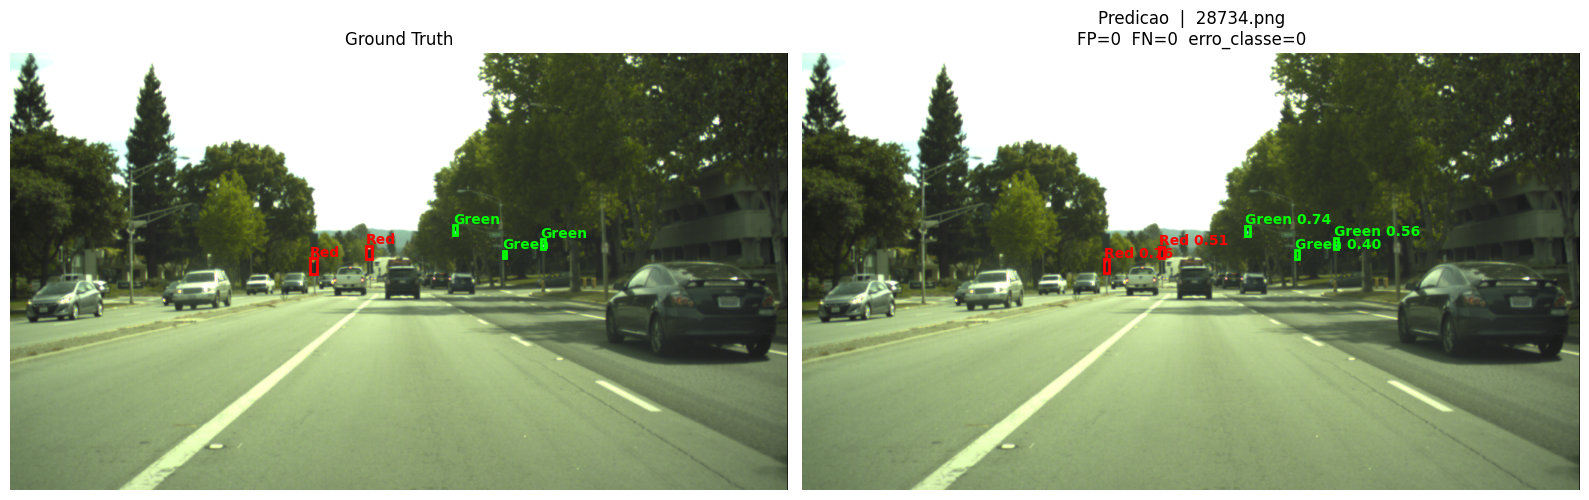

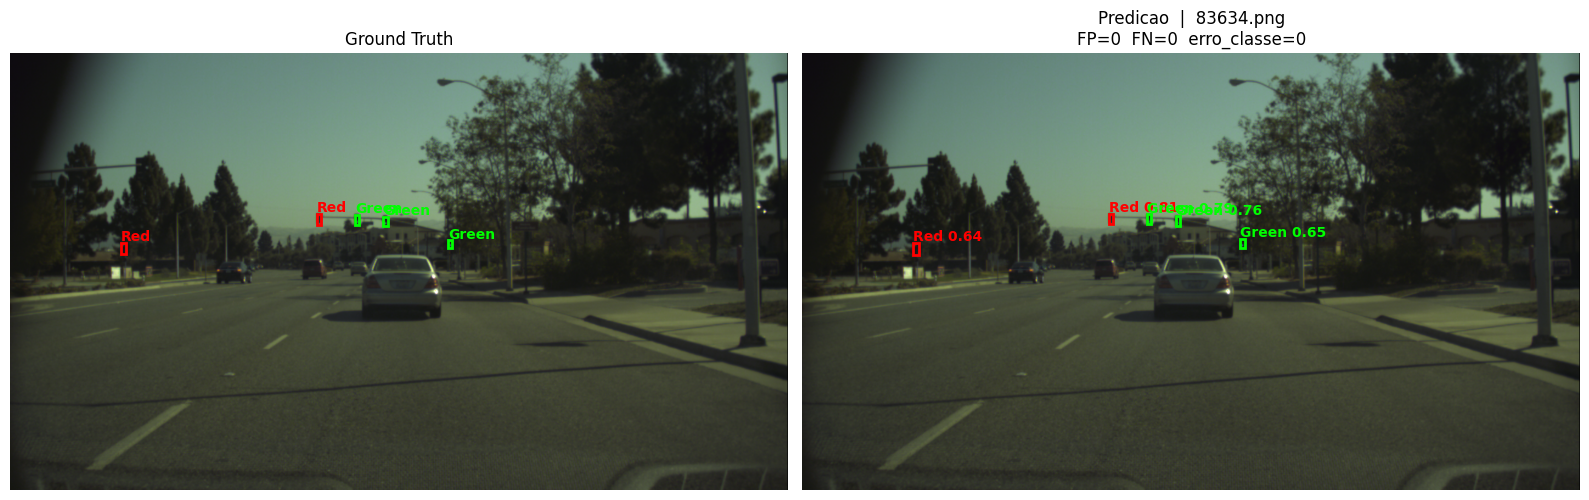

EXEMPLOS MAL SUCEDIDOS


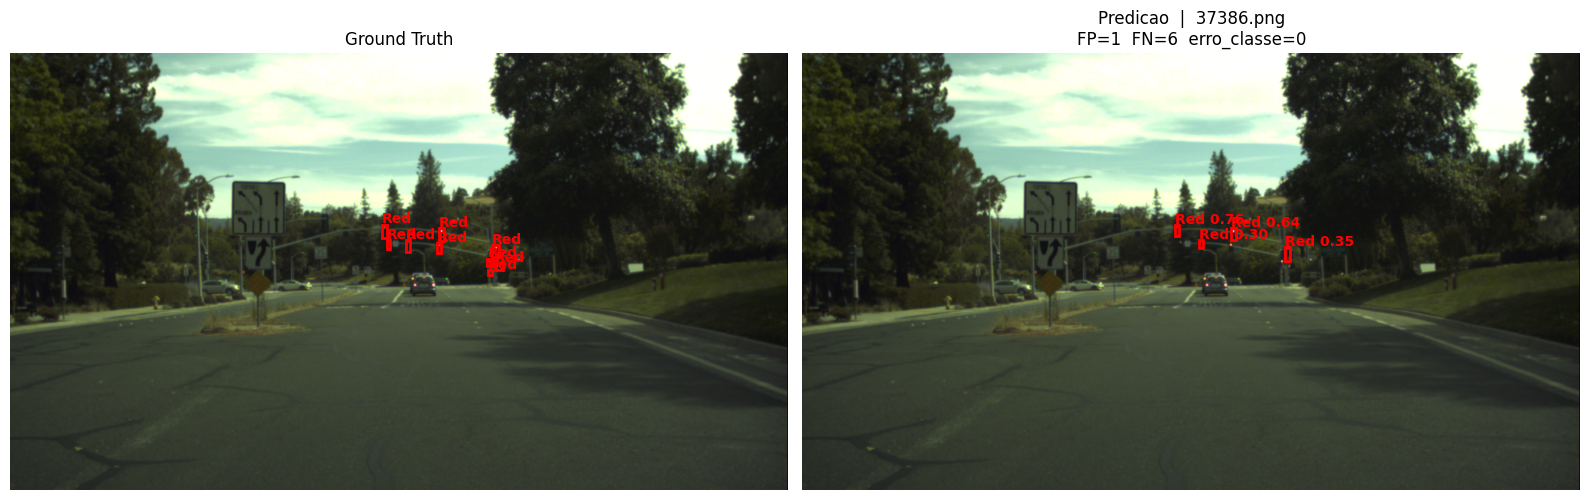

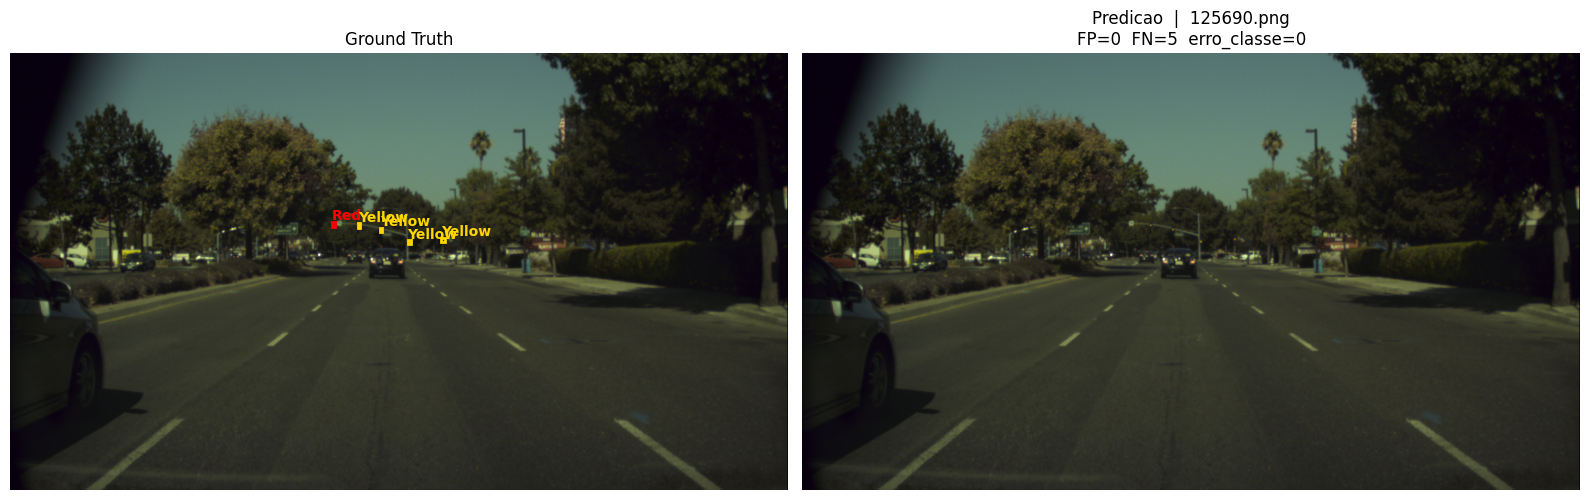

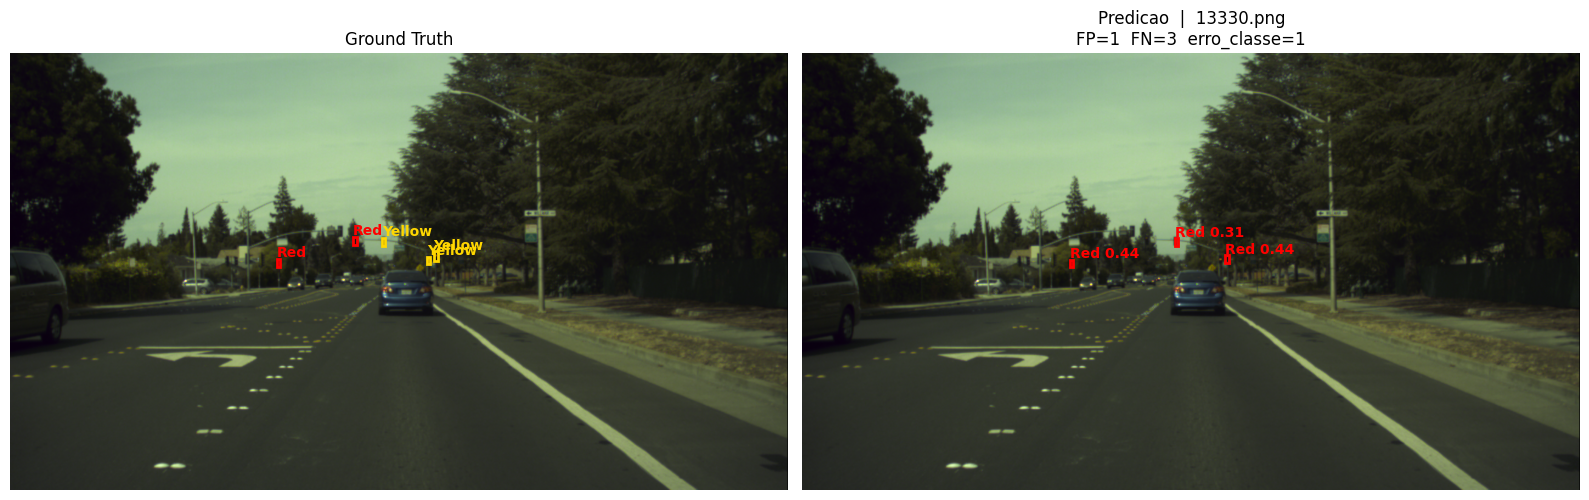

In [13]:
CLASS_NAMES = model.names            
CORES = {0: "red", 1: "gold", 2: "lime"}


def mostrar_exemplo(rec):
    img_path = rec["img"]
    img = Image.open(img_path)
    W, H = img.size
    gts = carregar_gt(TEST_LBL_DIR / f"{img_path.stem}.txt", W, H)
    res = model.predict(img_path, conf=CONF_VIS, iou=0.6, verbose=False)[0]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    for a in ax:
        a.imshow(img)
        a.axis("off")

    ax[0].set_title("Ground Truth")
    for cls, x1, y1, x2, y2 in gts:
        ax[0].add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, fill=False,
            edgecolor=CORES.get(cls, "white"), linewidth=2))
        ax[0].text(x1, y1 - 3, CLASS_NAMES[cls],
                   color=CORES.get(cls, "white"), fontsize=10, weight="bold")

    ax[1].set_title(
        f"Predicao  |  {img_path.name}\n"
        f"FP={rec['fp']}  FN={rec['fn']}  erro_classe={rec['erro_classe']}"
    )
    for box in res.boxes:
        cls = int(box.cls[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cf = float(box.conf[0])
        ax[1].add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, fill=False,
            edgecolor=CORES.get(cls, "white"), linewidth=2))
        ax[1].text(x1, y1 - 3, f"{CLASS_NAMES[cls]} {cf:.2f}",
                   color=CORES.get(cls, "white"), fontsize=10, weight="bold")

    plt.tight_layout()
    plt.show()


print("=" * 60)
print("EXEMPLOS BEM SUCEDIDOS")
print("=" * 60)
melhores = perfeitas.sort_values("n_gt", ascending=False).head(3)
for _, r in melhores.iterrows():
    mostrar_exemplo(r)

print("=" * 60)
print("EXEMPLOS MAL SUCEDIDOS")
print("=" * 60)
piores = com_erro.sort_values("erros", ascending=False).head(3)
for _, r in piores.iterrows():
    mostrar_exemplo(r)